<a href="https://colab.research.google.com/github/Elgendi/AI_Powered_Kiosk_Review2026/blob/main/AI_Powered_Kiosk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

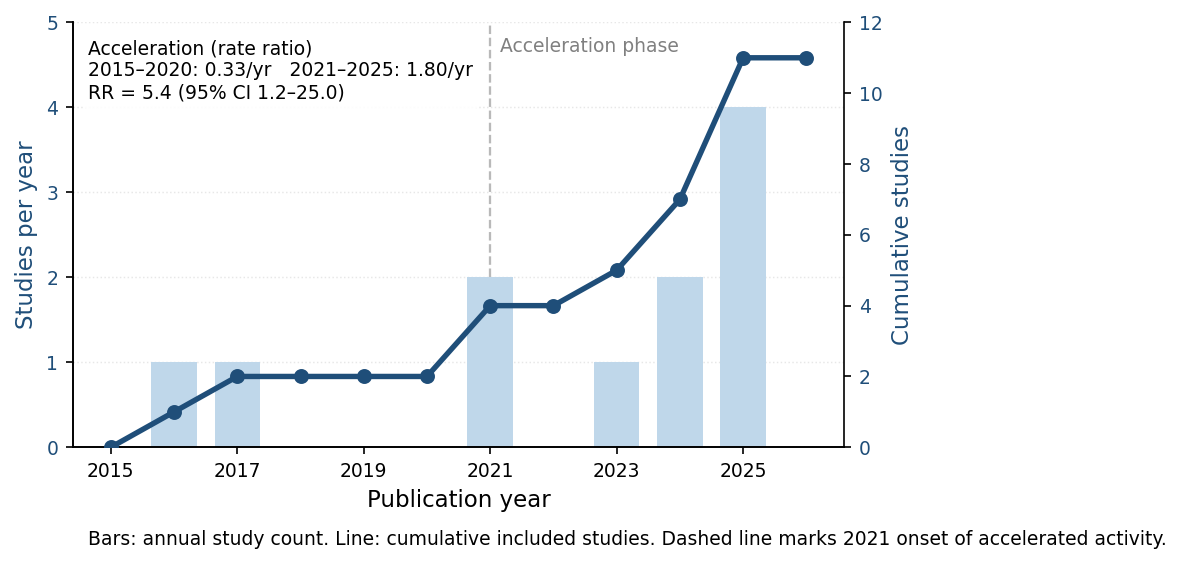

In [5]:
# Figure 2

import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# Data (edit if needed)
# -----------------------------
years = np.arange(2015, 2027)  # 2015–2026
pubs = np.zeros_like(years, dtype=int)

# Counts from your figure/caption (n=11)
year_to_count = {2016: 1, 2017: 1, 2021: 2, 2023: 1, 2024: 2, 2025: 4}
for y, c in year_to_count.items():
    pubs[years == y] = c

cum = np.cumsum(pubs)

# -----------------------------
# Simple, clean stat: "acceleration" pre vs post
# -----------------------------
pre_mask  = (years >= 2015) & (years <= 2020)
post_mask = (years >= 2021) & (years <= 2025)

k_pre  = int(pubs[pre_mask].sum())
k_post = int(pubs[post_mask].sum())
t_pre  = int(pre_mask.sum())
t_post = int(post_mask.sum())

rate_pre  = k_pre / t_pre if t_pre else np.nan
rate_post = k_post / t_post if t_post else np.nan
rr = (rate_post / rate_pre) if rate_pre > 0 else np.nan

# Approx 95% CI for RR (log-normal approximation)
# log(RR) ± 1.96*sqrt(1/k_post + 1/k_pre)
if k_pre > 0 and k_post > 0 and rr > 0:
    se = math.sqrt(1 / k_post + 1 / k_pre)
    rr_low  = math.exp(math.log(rr) - 1.96 * se)
    rr_high = math.exp(math.log(rr) + 1.96 * se)
else:
    rr_low, rr_high = np.nan, np.nan

# -----------------------------
# Plot (attractive but restrained)
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax1 = plt.subplots(figsize=(7.4, 3.9), dpi=150)

bar_color  = "#BFD7EA"  # soft light blue
line_color = "#1F4E79"  # deep blue

# Bars: studies per year (left axis)
ax1.bar(years, pubs, width=0.72, color=bar_color, edgecolor="none", zorder=2)
ax1.set_ylabel("Studies per year", color=line_color)
ax1.set_ylim(0, max(pubs) + 1)
ax1.tick_params(axis="y", labelcolor=line_color)

# Line: cumulative studies (right axis)
ax2 = ax1.twinx()
ax2.plot(years, cum, lw=2.6, color=line_color, zorder=4)
ax2.scatter(years, cum, s=38, color=line_color, zorder=5)
ax2.set_ylabel("Cumulative studies", color=line_color)
ax2.set_ylim(0, max(cum) + 1)
ax2.tick_params(axis="y", labelcolor=line_color)

# Inflection cue (subtle)
ax1.axvline(2021, lw=1.1, ls="--", color="gray", alpha=0.55, zorder=1)
ax1.text(2021.15, max(pubs) + 0.65, "Acceleration phase", fontsize=9, color="gray")

# Fix overlapped x labels:
# - show every 2nd year (you can switch to every year if you want)
xt = years[::2]  # 2015, 2017, 2019, ...
ax1.set_xticks(xt)
ax1.set_xticklabels([str(y) for y in xt], rotation=0)
ax1.set_xlim(years.min() - 0.6, years.max() + 0.6)
ax1.set_xlabel("Publication year")

# Light grid (y only)
ax1.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.30)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Clean stats callout (small, not cluttered)
callout = (
    f"Acceleration (rate ratio)\n"
    f"2015–2020: {rate_pre:.2f}/yr   2021–2025: {rate_post:.2f}/yr\n"
    f"RR = {rr:.1f} (95% CI {rr_low:.1f}–{rr_high:.1f})"
)
ax1.text(
    0.02, 0.96, callout,
    transform=ax1.transAxes,
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="none", alpha=0.90)
)

# Caption-style note (optional)
ax1.text(
    0.02, -0.23,
    "Bars: annual study count. Line: cumulative included studies. Dashed line marks 2021 onset of accelerated activity.",
    transform=ax1.transAxes,
    fontsize=9
)

plt.tight_layout()

# Save: high-res PNG + vector PDF
plt.savefig("Figure2_Timeline_DualAxis_Stats.png", dpi=600, bbox_inches="tight")
plt.savefig("Figure2_Timeline_DualAxis_Stats.pdf", bbox_inches="tight")
plt.show()


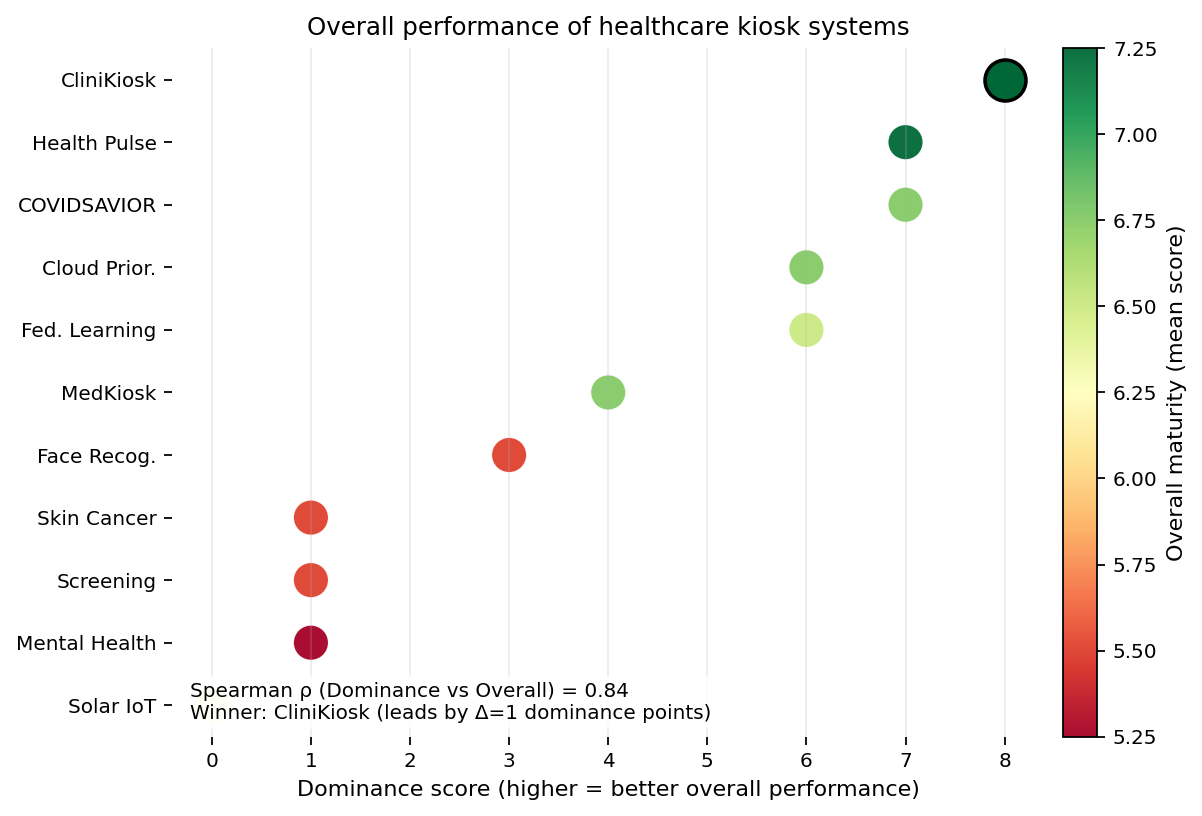

AI           8.00
IoT          5.00
Cloud        7.00
UI           9.00
Overall      7.25
Dominance    8.00
Name: CliniKiosk, dtype: float64
Spearman rho: 0.84


In [14]:
# ============================================================
# Figure 3
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

# ----------------------------
# 1) Data (from your figure)
# ----------------------------
data = {
    "AI": {
        "Fed. Learning": 9, "COVIDSAVIOR": 8, "MedKiosk": 8, "CliniKiosk": 8,
        "Face Recog.": 7, "Skin Cancer": 7, "Health Pulse": 7, "Cloud Prior.": 7,
        "Screening": 6, "Mental Health": 6, "Solar IoT": 5,
    },
    "IoT": {
        "Solar IoT": 10, "Health Pulse": 9, "COVIDSAVIOR": 8, "Screening": 6,
        "Cloud Prior.": 6, "Skin Cancer": 5, "Fed. Learning": 5, "CliniKiosk": 5,
        "Face Recog.": 4, "MedKiosk": 4, "Mental Health": 3,
    },
    "Cloud": {
        "Cloud Prior.": 9, "Fed. Learning": 8, "Health Pulse": 7, "CliniKiosk": 7,
        "COVIDSAVIOR": 6, "Solar IoT": 6, "Screening": 5, "Face Recog.": 5,
        "MedKiosk": 5, "Mental Health": 5, "Skin Cancer": 4,
    },
    "UI": {
        "MedKiosk": 10, "CliniKiosk": 9, "Mental Health": 7, "Face Recog.": 6,
        "Skin Cancer": 6, "Health Pulse": 6, "Screening": 5, "COVIDSAVIOR": 5,
        "Cloud Prior.": 5, "Fed. Learning": 4, "Solar IoT": 4,
    },
}

dims = ["AI", "IoT", "Cloud", "UI"]
systems = sorted({k for v in data.values() for k in v.keys()})

df = pd.DataFrame({k: pd.Series(v) for k, v in data.items()}, index=systems).astype(float)
df = df[dims]
df["Overall"] = df.mean(axis=1)

# ----------------------------
# 2) Dominance score (transparent + simple)
# "wins" against another system if it is >= in at least 3/4 dimensions
# ----------------------------
dominance = {}
for a in df.index:
    score = 0
    for b in df.index:
        if a == b:
            continue
        if (df.loc[a, dims] >= df.loc[b, dims]).sum() >= 3:
            score += 1
    dominance[a] = score

df["Dominance"] = pd.Series(dominance)

# Sort by dominance (ascending for plotting bottom-to-top trend)
dfp = df.sort_values(["Dominance", "Overall"], ascending=[True, True]).copy()

# Identify best + runner-up by dominance
best = df.sort_values(["Dominance", "Overall"], ascending=[False, False]).index[0]
second = df.sort_values(["Dominance", "Overall"], ascending=[False, False]).index[1]
delta_dom = int(df.loc[best, "Dominance"] - df.loc[second, "Dominance"])

# ----------------------------
# 3) Simple stats: Spearman rank correlation (no SciPy needed)
# Spearman = Pearson corr of ranks
# ----------------------------
def spearman_rank_corr(x, y):
    xr = pd.Series(x).rank(method="average").values
    yr = pd.Series(y).rank(method="average").values
    xr = xr - xr.mean()
    yr = yr - yr.mean()
    denom = (np.sqrt((xr**2).sum()) * np.sqrt((yr**2).sum()))
    return float((xr * yr).sum() / denom) if denom > 0 else np.nan

rho = spearman_rank_corr(df["Dominance"].values, df["Overall"].values)

# ----------------------------
# 4) Plot styling (npjDM clean)
# - Green best, red worst colormap
# - Robust normalization so colors match meaning
# ----------------------------
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 600,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

fig = plt.figure(figsize=(7.6, 5.2))
ax = plt.gca()

# Color mapping: red (low) -> green (high)
cmap = plt.cm.RdYlGn
norm = colors.Normalize(vmin=dfp["Overall"].min(), vmax=dfp["Overall"].max())

# Base points (circles only)
sc = ax.scatter(
    dfp["Dominance"],
    dfp.index,
    s=260,
    c=dfp["Overall"],
    cmap=cmap,
    norm=norm,
    alpha=0.95,
    edgecolors="white",
    linewidths=0.8
)

# Highlight best system (professional: subtle black outline + slightly larger)
ax.scatter(
    df.loc[best, "Dominance"],
    best,
    s=340,
    facecolors=cmap(norm(df.loc[best, "Overall"])),
    edgecolors="black",
    linewidths=1.6,
    zorder=5
)

# Label best without star
ax.text(
    df.loc[best, "Dominance"] + 0.25,
    best,
    "",
    va="center",
    fontsize=11,
    weight="bold"
)

# Axes labels/title (short, clinical)
ax.set_title("Overall performance of healthcare kiosk systems")
ax.set_xlabel("Dominance score (higher = better overall performance)")

# Grid + spines (Nature-like minimal)
ax.grid(axis="x", alpha=0.25)
for spine in ax.spines.values():
    spine.set_visible(False)

# Colorbar (explicit best/worst)
cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.05)
cbar.set_label("Overall maturity (mean score)", rotation=90)

# Add a small legend-like text for interpretation + stats
stats_text = (
    f"Spearman ρ (Dominance vs Overall) = {rho:.2f}\n"
    f"Winner: {best} (leads by Δ={delta_dom} dominance points)"
)
ax.text(
    0.02, 0.02,
    stats_text,
    transform=ax.transAxes,
    fontsize=9,
    va="bottom",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.85)
)

plt.tight_layout()

# Save (high-res PNG + vector PDF)
plt.savefig("dominance_overall_professional.png", dpi=600, bbox_inches="tight")
plt.savefig("dominance_overall_professional.pdf", bbox_inches="tight")

plt.show()

print(df.loc[best, dims + ["Overall", "Dominance"]].round(3))
print("Spearman rho:", round(rho, 3))


/tmp/ipython-input-3259644300.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.955])


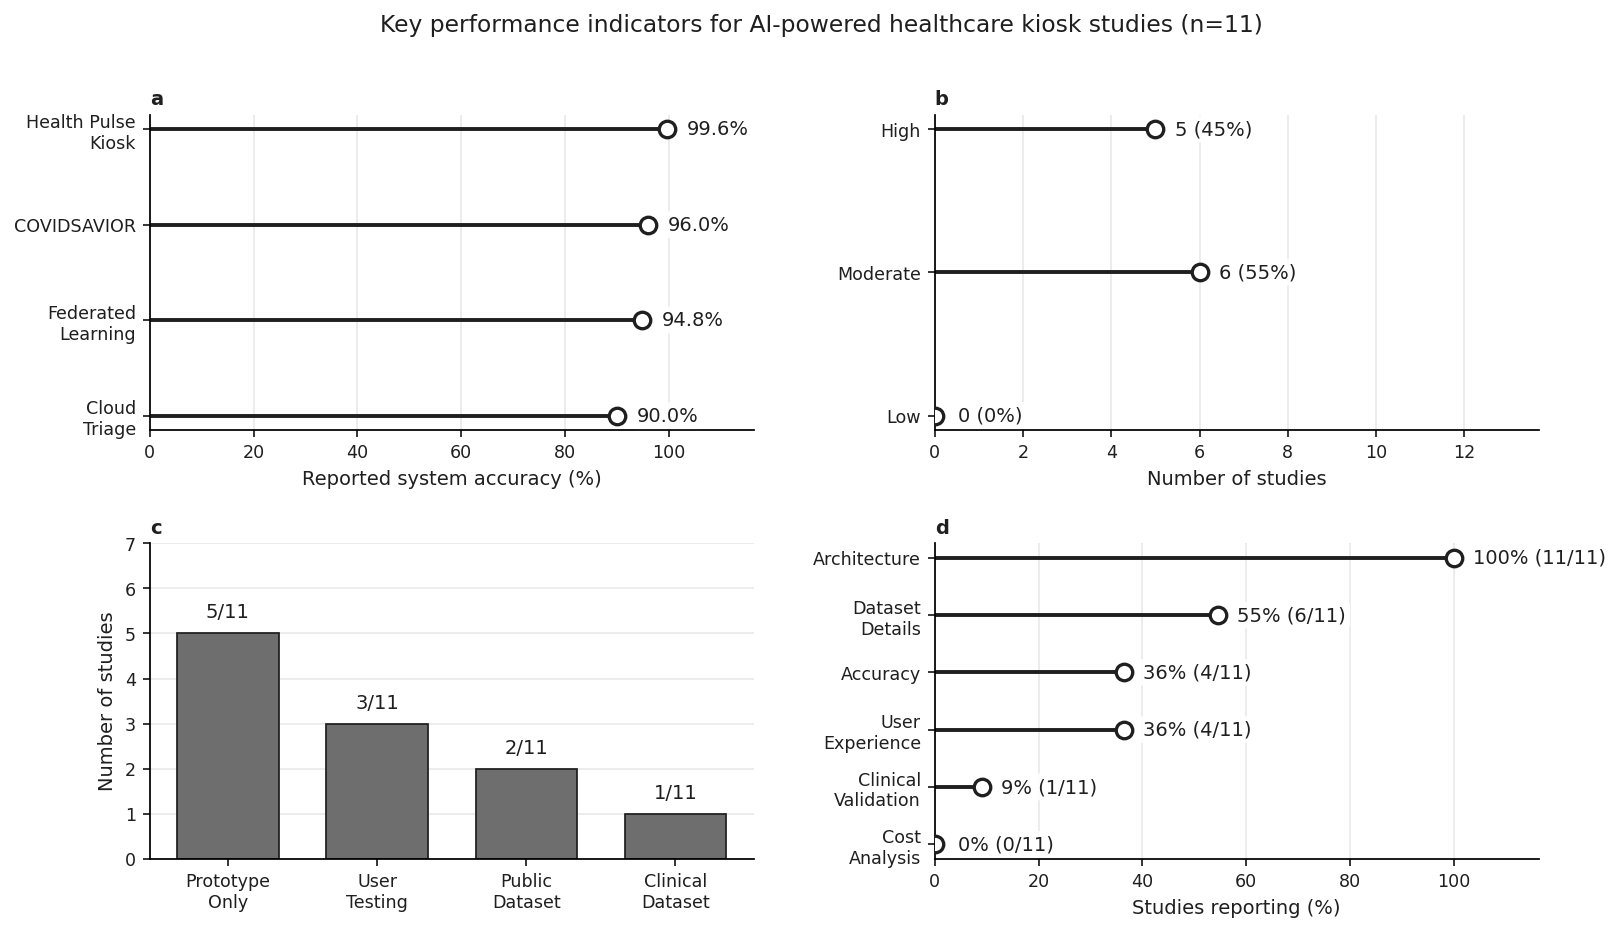

Saved: KPI_dashboard_nature_clean.png and KPI_dashboard_nature_clean.pdf


In [17]:
# ============================================================
# Figure 6
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -------------------------
# Data
# -------------------------
N = 11

accuracy = {
    "Health Pulse\nKiosk": 99.6,
    "COVIDSAVIOR": 96.0,
    "Federated\nLearning": 94.8,
    "Cloud\nTriage": 90.0,
}

risk_of_bias = {"High": 5, "Moderate": 6, "Low": 0}  # display order
validation_stage = {"Prototype\nOnly": 5, "User\nTesting": 3, "Public\nDataset": 2, "Clinical\nDataset": 1}
reporting = {
    "Architecture": 11,
    "Dataset\nDetails": 6,
    "Accuracy": 4,
    "User\nExperience": 4,
    "Clinical\nValidation": 1,
    "Cost\nAnalysis": 0,
}

# -------------------------
# Global style (lighter, journal-like)
# -------------------------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
})

INK = "#1f1f1f"
GRID = "#d9d9d9"

STEM_W = 2.0              # lollipop stem width (lighter than before)
MARKER_S = 72             # marker size
MARKER_LW = 1.7           # marker edge width

BAR_FILL = "#6e6e6e"      # soft gray (not harsh black)
BAR_EDGE = "#1f1f1f"

def panel_label(ax, s):
    ax.text(0.0, 1.02, s, transform=ax.transAxes, ha="left", va="bottom",
            fontweight="bold", color=INK)

def style_axis(ax, grid_axis="x"):
    ax.tick_params(colors=INK, width=0.9)
    ax.set_axisbelow(True)
    # Subtle grid only on one axis
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.9, alpha=0.55)

def safe_annotate(ax, x, y, text, dx=10, dy=0, ha="left"):
    # Clean label: white background, no heavy box edge
    ax.annotate(
        text, (x, y),
        xytext=(dx, dy), textcoords="offset points",
        ha=ha, va="center", color=INK,
        bbox=dict(boxstyle="round,pad=0.20", fc="white", ec="none", alpha=0.95)
    )

def add_xpad(ax, frac=0.12):
    xmin, xmax = ax.get_xlim()
    span = xmax - xmin
    ax.set_xlim(xmin, xmax + frac * span)

def lollipop(ax, y, xvals, labels, xlim, xlabel, value_fmt, value_extra=None, panel="a"):
    """
    Draw a clean lollipop chart (horizontal).
    - Open circles (white fill) with black edge.
    - Thin stems.
    - Non-overlapping labels in white callouts.
    """
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=INK)
    ax.invert_yaxis()
    ax.set_xlim(*xlim)
    add_xpad(ax, frac=0.14)

    for yi, xv in zip(y, xvals):
        # stem
        ax.plot([0, xv], [yi, yi], color=INK, linewidth=STEM_W, solid_capstyle="round", zorder=2)
        # marker (open circle)
        ax.scatter([xv], [yi], s=MARKER_S, facecolor="white", edgecolor=INK,
                   linewidth=MARKER_LW, zorder=3)

        # label text
        base = value_fmt(xv)
        extra = "" if value_extra is None else value_extra(xv, yi)
        txt = base + extra

        # make zeros readable (push further)
        dx = 12 if xv == 0 else 10
        safe_annotate(ax, xv, yi, txt, dx=dx, dy=0, ha="left")

    ax.set_xlabel(xlabel, color=INK)
    style_axis(ax, grid_axis="x")
    panel_label(ax, panel)

# -------------------------
# Build figure
# -------------------------
fig = plt.figure(figsize=(12.8, 6.9))
gs = GridSpec(2, 2, figure=fig, wspace=0.30, hspace=0.36)

fig.suptitle("Key performance indicators for AI-powered healthcare kiosk studies (n=11)",
             y=0.985, color=INK)

# ===== (a) Accuracy =====
ax = fig.add_subplot(gs[0, 0])
labels = list(accuracy.keys())
vals = np.array([accuracy[k] for k in labels])

# Sort descending
order = np.argsort(vals)[::-1]
labels = [labels[i] for i in order]
vals = vals[order]
y = np.arange(len(labels))

lollipop(
    ax=ax,
    y=y,
    xvals=vals,
    labels=labels,
    xlim=(0, 102),
    xlabel="Reported system accuracy (%)",
    value_fmt=lambda v: f"{v:.1f}%",
    panel="a",
)

# ===== (b) Risk of bias =====
ax = fig.add_subplot(gs[0, 1])
cats = list(risk_of_bias.keys())
v = np.array([risk_of_bias[c] for c in cats])
y = np.arange(len(cats))

def rob_extra(xv, yi):
    pct = 100 * xv / N
    return f" ({pct:.0f}%)"

lollipop(
    ax=ax,
    y=y,
    xvals=v,
    labels=cats,
    xlim=(0, 12),
    xlabel="Number of studies",
    value_fmt=lambda v: f"{int(v)}",
    value_extra=rob_extra,
    panel="b",
)

# ===== (c) Validation stage (lighter bars + crisp edge) =====
ax = fig.add_subplot(gs[1, 0])
cats = list(validation_stage.keys())
v = np.array([validation_stage[c] for c in cats])
x = np.arange(len(cats))

bars = ax.bar(x, v, width=0.68, color=BAR_FILL, edgecolor=BAR_EDGE, linewidth=0.9)

for xi, vv in zip(x, v):
    ax.annotate(
        f"{vv}/{N}", (xi, vv),
        xytext=(0, 6), textcoords="offset points",
        ha="center", va="bottom", color=INK,
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.95)
    )

ax.set_xticks(x)
ax.set_xticklabels(cats, color=INK)
ax.set_ylabel("Number of studies", color=INK)
ax.set_ylim(0, max(7, v.max() + 2))
ax.grid(axis="y", color=GRID, linewidth=0.9, alpha=0.55)
ax.set_axisbelow(True)
ax.tick_params(colors=INK, width=0.9)
panel_label(ax, "c")

# ===== (d) Reporting completeness =====
ax = fig.add_subplot(gs[1, 1])
cats = list(reporting.keys())
counts = np.array([reporting[c] for c in cats])
pct = 100 * counts / N

# Sort descending
order = np.argsort(pct)[::-1]
cats = [cats[i] for i in order]
counts = counts[order]
pct = pct[order]
y = np.arange(len(cats))

def rep_extra(xv, yi):
    cc = counts[int(yi)]
    return f"% ({cc}/{N})"

lollipop(
    ax=ax,
    y=y,
    xvals=pct,
    labels=cats,
    xlim=(0, 102),
    xlabel="Studies reporting (%)",
    value_fmt=lambda v: f"{v:.0f}",
    value_extra=rep_extra,
    panel="d",
)

# Final layout + export
plt.tight_layout(rect=[0, 0, 1, 0.955])
fig.savefig("KPI_dashboard_nature_clean.png", dpi=300, bbox_inches="tight")
fig.savefig("KPI_dashboard_nature_clean.pdf", bbox_inches="tight")
plt.show()



/tmp/ipython-input-3647881213.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


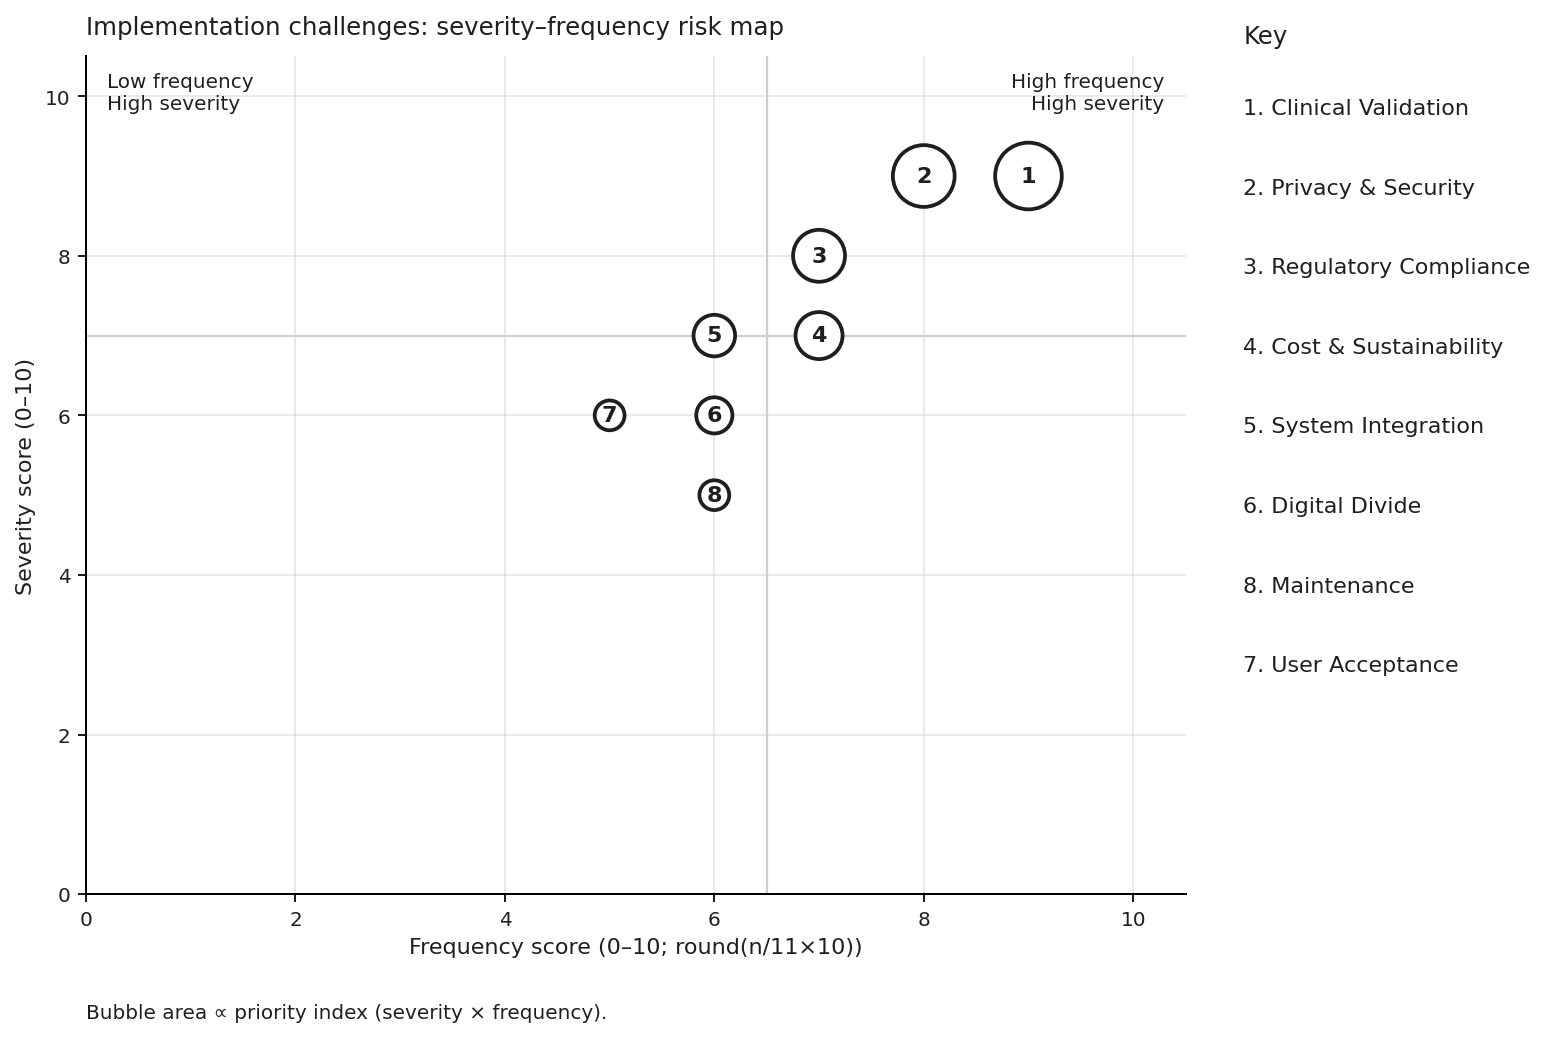

Saved: fig7_riskmap_clean.png and fig7_riskmap_clean.pdf


In [23]:
# ============================================================
# Figure 7
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Data
# -------------------------
items = [
    ("Clinical Validation",        9, 9),
    ("Privacy & Security",         8, 9),
    ("Regulatory Compliance",      7, 8),
    ("Cost & Sustainability",      7, 7),
    ("System Integration",         6, 7),
    ("Digital Divide",             6, 6),
    ("User Acceptance",            5, 6),
    ("Maintenance",                6, 5),
]
labels = [t[0] for t in items]
freq   = np.array([t[1] for t in items], dtype=float)
sev    = np.array([t[2] for t in items], dtype=float)

# -------------------------
# Style
# -------------------------
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
})

INK = "#1f1f1f"
GRID = "#d9d9d9"

# Bubble sizes: area proportional to priority (sev*freq)
priority = sev * freq
s_min, s_max = 180, 900
sizes = s_min + (s_max - s_min) * (priority - priority.min()) / (priority.max() - priority.min() + 1e-9)

# -------------------------
# Layout: main plot + compact key
# -------------------------
fig = plt.figure(figsize=(11.2, 6.8))
gs = fig.add_gridspec(1, 5, wspace=0.25)
ax = fig.add_subplot(gs[0, :4])
ax_key = fig.add_subplot(gs[0, 4])

# Main plot styling
ax.grid(True, color=GRID, lw=0.9, alpha=0.55)
ax.set_axisbelow(True)

# Quadrant reference lines (median)
x_med, y_med = np.median(freq), np.median(sev)
ax.axvline(x_med, color="#cfcfcf", lw=1.0)
ax.axhline(y_med, color="#cfcfcf", lw=1.0)

# Bubbles (open circles, monochrome)
ax.scatter(freq, sev, s=sizes, facecolor="white", edgecolor=INK, linewidth=1.7, zorder=3)

# Number inside each bubble (no arrows, no label clutter)
for i, (x, y) in enumerate(zip(freq, sev), start=1):
    ax.text(x, y, str(i), ha="center", va="center", color=INK, fontweight="bold", fontsize=10, zorder=4)

# Axes
ax.set_xlim(0, 10.5)
ax.set_ylim(0, 10.5)
ax.set_xticks(np.arange(0, 11, 2))
ax.set_yticks(np.arange(0, 11, 2))
ax.set_xlabel("Frequency score (0–10; round(n/11×10))", color=INK)
ax.set_ylabel("Severity score (0–10)", color=INK)
ax.set_title("Implementation challenges: severity–frequency risk map", loc="left", color=INK, pad=10)
ax.tick_params(colors=INK, width=0.9)

# Minimal corner cues (optional; keep subtle)
ax.text(0.2, 10.3, "Low frequency\nHigh severity", ha="left", va="top", fontsize=9, color=INK)
ax.text(10.3, 10.3, "High frequency\nHigh severity", ha="right", va="top", fontsize=9, color=INK)

# Footnote (subtle)
ax.text(0.0, -0.13, "Bubble area ∝ priority index (severity × frequency).",
        transform=ax.transAxes, ha="left", va="top", fontsize=9, color=INK)

# -------------------------
# Right-side key (clean list)
# -------------------------
ax_key.axis("off")
ax_key.set_title("Key", loc="left", color=INK, pad=6)

# Sort key by priority (descending) so top items appear first
order = np.argsort(priority)[::-1]
lines = []
for rank, idx in enumerate(order, start=1):
    i = idx + 1  # bubble number
    lines.append(f"{i}. {labels[idx]}")

# Draw text lines
y0 = 0.95
dy = 0.095
for k, line in enumerate(lines):
    ax_key.text(0.0, y0 - k*dy, line, ha="left", va="top", color=INK)

plt.tight_layout()
fig.savefig("fig7_riskmap_clean.png", dpi=300, bbox_inches="tight")
fig.savefig("fig7_riskmap_clean.pdf", bbox_inches="tight")
plt.show()



/tmp/ipython-input-1170047471.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


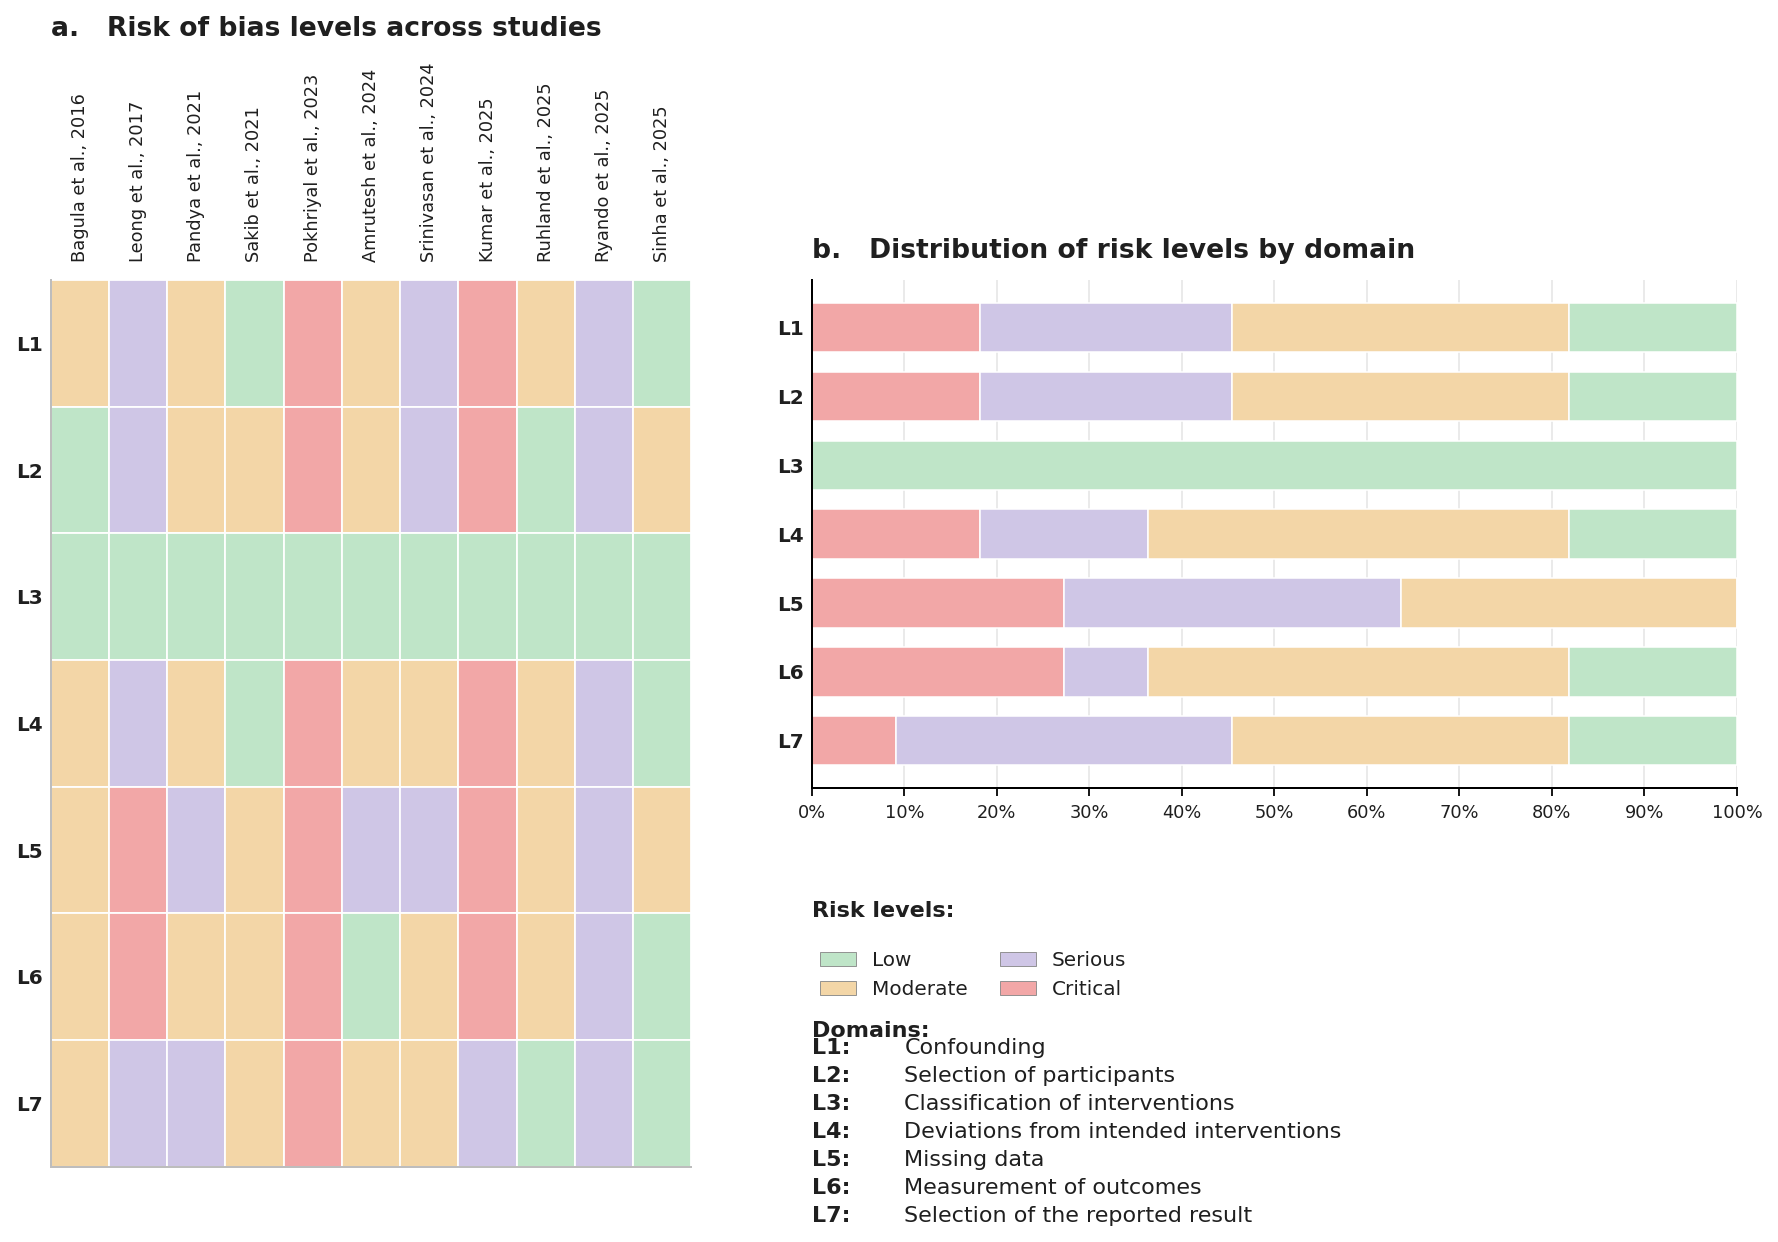

Saved: fig8_robinsI_top1_v2.png and fig8_robinsI_top1_v2.pdf


In [26]:
# ============================================================
# Figure 8
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# -------------------------
# 1) INPUTS (replace with your exact values)
# -------------------------
studies = [
    "Bagula et al., 2016",
    "Leong et al., 2017",
    "Pandya et al., 2021",
    "Sakib et al., 2021",
    "Pokhriyal et al., 2023",
    "Amrutesh et al., 2024",
    "Srinivasan et al., 2024",
    "Kumar et al., 2025",
    "Ruhland et al., 2025",
    "Ryando et al., 2025",
    "Sinha et al., 2025",
]
domains = ["L1", "L2", "L3", "L4", "L5", "L6", "L7"]

# Risk encoding: 0=Low, 1=Moderate, 2=Serious, 3=Critical
# Replace with your real ROBINS-I matrix (7 x 11)
M = np.array([
    [1,2,1,0,3,1,2,3,1,2,0],  # L1
    [0,2,1,1,3,1,2,3,0,2,1],  # L2
    [0,0,0,0,0,0,0,0,0,0,0],  # L3
    [1,2,1,0,3,1,1,3,1,2,0],  # L4
    [1,3,2,1,3,2,2,3,1,2,1],  # L5
    [1,3,1,1,3,0,1,3,1,2,0],  # L6
    [1,2,2,1,3,1,1,2,0,2,0],  # L7
], dtype=int)

assert M.shape == (len(domains), len(studies))

# -------------------------
# 2) PALETTE (muted, Nature-friendly, categorical)
#    Low, Moderate, Serious, Critical
# -------------------------
COLORS = {
    0: "#BFE5C8",  # Low (muted green)
    1: "#F3D6A7",  # Moderate (sand)
    2: "#CFC6E6",  # Serious (soft violet)
    3: "#F2A7A7",  # Critical (muted rose)
}
LEVEL_NAMES = {0:"Low", 1:"Moderate", 2:"Serious", 3:"Critical"}

# -------------------------
# 3) STYLE
# -------------------------
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
})

INK  = "#1f1f1f"
GRID = "#d9d9d9"

# -------------------------
# 4) DOMAIN DISTRIBUTIONS
# -------------------------
counts = np.zeros((len(domains), 4), dtype=int)
for i in range(len(domains)):
    for lvl in range(4):
        counts[i, lvl] = np.sum(M[i] == lvl)

pct = counts / counts.sum(axis=1, keepdims=True) * 100.0

# -------------------------
# 5) LAYOUT (more proportional + no overlap)
# -------------------------
fig = plt.figure(figsize=(13.6, 7.2))

# More space on top reserved for rotated labels (prevents title clash)
# Two rows: top = plots, bottom = legend block
gs = GridSpec(
    2, 3, figure=fig,
    width_ratios=[2.35, 1.85, 1.10],
    height_ratios=[1.0, 0.55],
    wspace=0.25, hspace=0.25
)

ax_hm  = fig.add_subplot(gs[:, 0])     # left: heatmap spans both rows
ax_bar = fig.add_subplot(gs[0, 1:])    # right-top: stacked bars
ax_key = fig.add_subplot(gs[1, 1:])    # right-bottom: legend + domain key

# -------------------------
# 6) PANEL a: HEATMAP
# -------------------------
ax_hm.set_title("a.   Risk of bias levels across studies", loc="left",
                pad=12, color=INK, fontweight="bold")

n_rows, n_cols = M.shape
ax_hm.set_xlim(0, n_cols)
ax_hm.set_ylim(0, n_rows)
ax_hm.invert_yaxis()

# Draw cells with thin separators
for r in range(n_rows):
    for c in range(n_cols):
        ax_hm.add_patch(
            plt.Rectangle(
                (c, r), 1, 1,
                facecolor=COLORS[M[r, c]],
                edgecolor="white",
                linewidth=0.8
            )
        )

# Ticks: place labels on top, rotate, and add extra padding
ax_hm.set_xticks(np.arange(n_cols) + 0.5)
ax_hm.set_xticklabels(studies, rotation=90, ha="center", va="bottom", color=INK)
ax_hm.xaxis.tick_top()
ax_hm.tick_params(axis="x", length=0, pad=8)  # PAD helps avoid collisions
ax_hm.set_yticks(np.arange(n_rows) + 0.5)
ax_hm.set_yticklabels(domains, color=INK, fontweight="bold")
ax_hm.tick_params(axis="y", length=0)

# Subtle boundary
for spine in ["left", "bottom"]:
    ax_hm.spines[spine].set_color("#bdbdbd")

# -------------------------
# 7) PANEL b: STACKED BARS
# -------------------------
ax_bar.set_title("b.   Distribution of risk levels by domain", loc="left",
                 pad=10, color=INK, fontweight="bold")

y = np.arange(len(domains))
left = np.zeros(len(domains))

# stack order: Critical -> Serious -> Moderate -> Low (ending with Low to the right)
order_levels = [3, 2, 1, 0]
for lvl in order_levels:
    ax_bar.barh(
        y, pct[:, lvl], left=left,
        color=COLORS[lvl], edgecolor="white",
        linewidth=0.7, height=0.72
    )
    left += pct[:, lvl]

ax_bar.set_yticks(y)
ax_bar.set_yticklabels(domains, color=INK, fontweight="bold")
ax_bar.invert_yaxis()
ax_bar.set_xlim(0, 100)
ax_bar.set_xticks(np.arange(0, 101, 10))
ax_bar.set_xticklabels([f"{t}%" for t in range(0, 101, 10)], color=INK)
ax_bar.grid(axis="x", color=GRID, linewidth=0.9, alpha=0.55)
ax_bar.set_axisbelow(True)
ax_bar.tick_params(axis="y", length=0)

# -------------------------
# 8) LEGEND + DOMAIN KEY (compact + aligned)
# -------------------------
ax_key.axis("off")

# Risk legend
ax_key.text(0.00, 0.95, "Risk levels:", ha="left", va="top",
            color=INK, fontweight="bold", transform=ax_key.transAxes)

handles = [
    mpatches.Patch(facecolor=COLORS[0], edgecolor="#8a8a8a", linewidth=0.4, label="Low"),
    mpatches.Patch(facecolor=COLORS[1], edgecolor="#8a8a8a", linewidth=0.4, label="Moderate"),
    mpatches.Patch(facecolor=COLORS[2], edgecolor="#8a8a8a", linewidth=0.4, label="Serious"),
    mpatches.Patch(facecolor=COLORS[3], edgecolor="#8a8a8a", linewidth=0.4, label="Critical"),
]
leg = ax_key.legend(handles=handles, ncol=2, frameon=False, loc="upper left",
                    bbox_to_anchor=(0.00, 0.80), borderaxespad=0.0,
                    handlelength=1.8, columnspacing=1.6)
for t in leg.get_texts():
    t.set_color(INK)

# Domain descriptions
domain_desc = [
    ("L1", "Confounding"),
    ("L2", "Selection of participants"),
    ("L3", "Classification of interventions"),
    ("L4", "Deviations from intended interventions"),
    ("L5", "Missing data"),
    ("L6", "Measurement of outcomes"),
    ("L7", "Selection of the reported result"),
]

ax_key.text(0.00, 0.52, "Domains:", ha="left", va="top",
            color=INK, fontweight="bold", transform=ax_key.transAxes)

y0, dy = 0.46, 0.10
for i, (k, d) in enumerate(domain_desc):
    ax_key.text(0.00, y0 - i*dy, f"{k}:", ha="left", va="top",
                color=INK, fontweight="bold", transform=ax_key.transAxes)
    ax_key.text(0.10, y0 - i*dy, d, ha="left", va="top",
                color=INK, transform=ax_key.transAxes)

# -------------------------
# 9) MAIN TITLE (positioned safely)
# -------------------------

# Reserve top space so suptitle NEVER intersects tick labels
plt.tight_layout(rect=[0, 0, 1, 0.92])

fig.savefig("fig8_robinsI_top1_v2.png", dpi=300, bbox_inches="tight")
fig.savefig("fig8_robinsI_top1_v2.pdf", bbox_inches="tight")
plt.show()

print("Saved: fig8_robinsI_top1_v2.png and fig8_robinsI_top1_v2.pdf")
